### Importing Libraries

In [43]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder,LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
#from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings("ignore")


### DATA LOADING

In [44]:
df=pd.read_csv('food_waste_prediction_dataset_1000_rows.csv')
df.head()

,Day_of_Week,Festival,Weather,Expected_Customers,Previous_Day_Consumption,Previous_Week_Same_Day,Meals_Consumed
0,Thursday,0,Cloudy,572,352,361,512
1,Sunday,0,Rainy,486,512,509,385
2,Wednesday,0,Sunny,516,385,390,460
3,Sunday,0,Rainy,462,460,480,337
4,Thursday,0,Cloudy,402,337,327,316


In [45]:
df.shape

(1000, 7)

In [46]:
df.duplicated().sum()

0

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Day_of_Week               1000 non-null   object
 1   Festival                  1000 non-null   int64 
 2   Weather                   1000 non-null   object
 3   Expected_Customers        1000 non-null   int64 
 4   Previous_Day_Consumption  1000 non-null   int64 
 5   Previous_Week_Same_Day    1000 non-null   int64 
 6   Meals_Consumed            1000 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 54.8+ KB


In [48]:
df.describe()

,Festival,Expected_Customers,Previous_Day_Consumption,Previous_Week_Same_Day,Meals_Consumed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.103000,474.430000,396.360000,398.821000,396.483000
std,0.304111,72.490012,72.968917,72.123344,72.997729
min,0.000000,350.000000,240.000000,300.000000,240.000000
25%,0.000000,412.000000,337.000000,337.000000,337.000000
50%,0.000000,474.000000,393.000000,392.500000,393.000000
75%,0.000000,535.250000,450.000000,450.250000,450.250000
max,1.000000,600.000000,606.000000,660.000000,606.000000


In [49]:
df['Festival'].value_counts()

Festival
0    897
1    103
Name: count, dtype: int64

In [50]:
df['Expected_Customers'].nunique()

246

In [51]:
df.isnull().sum()

Day_of_Week                 0
Festival                    0
Weather                     0
Expected_Customers          0
Previous_Day_Consumption    0
Previous_Week_Same_Day      0
Meals_Consumed              0
dtype: int64

###  EXPLORATORY DATA ANALYSIS (EDA)

In [52]:
Av_food_spoid=sum(df['Expected_Customers'])/df.shape[0]-sum(df['Meals_Consumed'])/df.shape[0]
Av_food_spoid

77.947

In [53]:
df['Expected_Customers'].value_counts(ascending=True)

Expected_Customers
551     1
475     1
497     1
472     1
416     1
       ..
592     9
487     9
565     9
470    10
514    11
Name: count, Length: 246, dtype: int64

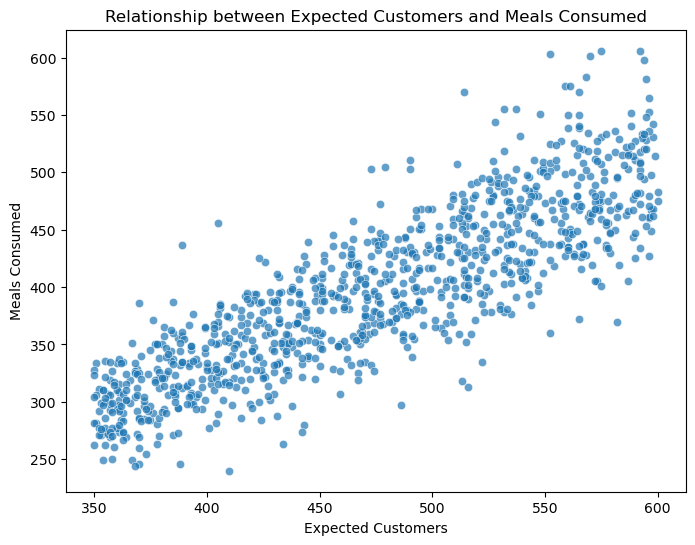

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(x='Expected_Customers', y='Meals_Consumed', data=df, alpha=0.7)
plt.title("Relationship between Expected Customers and Meals Consumed")
plt.xlabel("Expected Customers")
plt.ylabel("Meals Consumed")
plt.show()


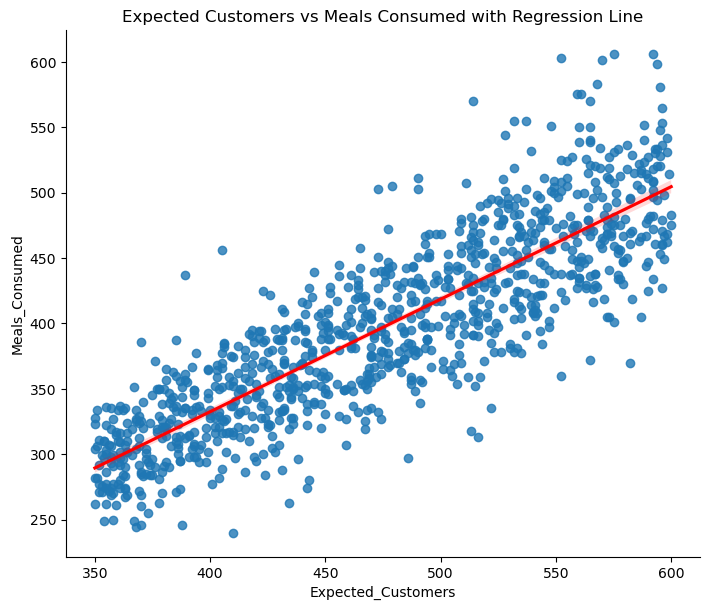

In [55]:
sns.lmplot(x='Expected_Customers', y='Meals_Consumed', data=df, height=6, aspect=1.2, line_kws={"color":"red"})
plt.title("Expected Customers vs Meals Consumed with Regression Line")
plt.show()


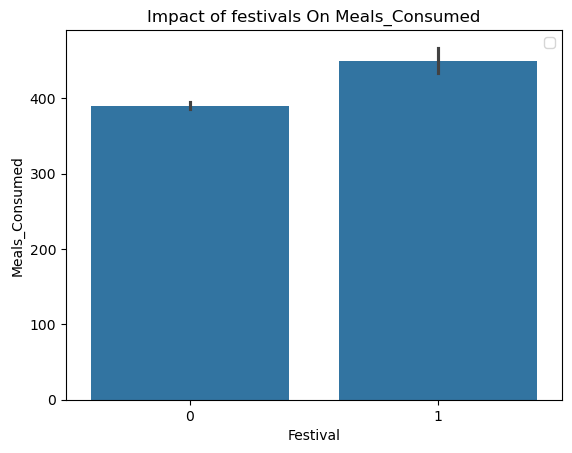

In [56]:
sns.barplot(x='Festival', y='Meals_Consumed', data=df)
plt.title("Impact of festivals On Meals_Consumed")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Impact of Weather  On Meals_Consumed')

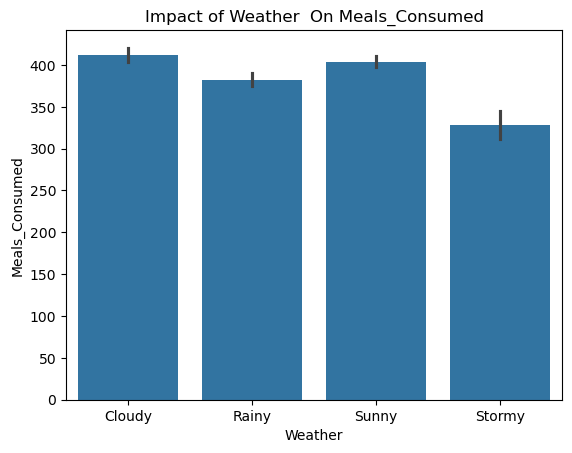

In [57]:
sns.barplot(x="Weather",y='Meals_Consumed',data=df)
plt.title("Impact of Weather  On Meals_Consumed")


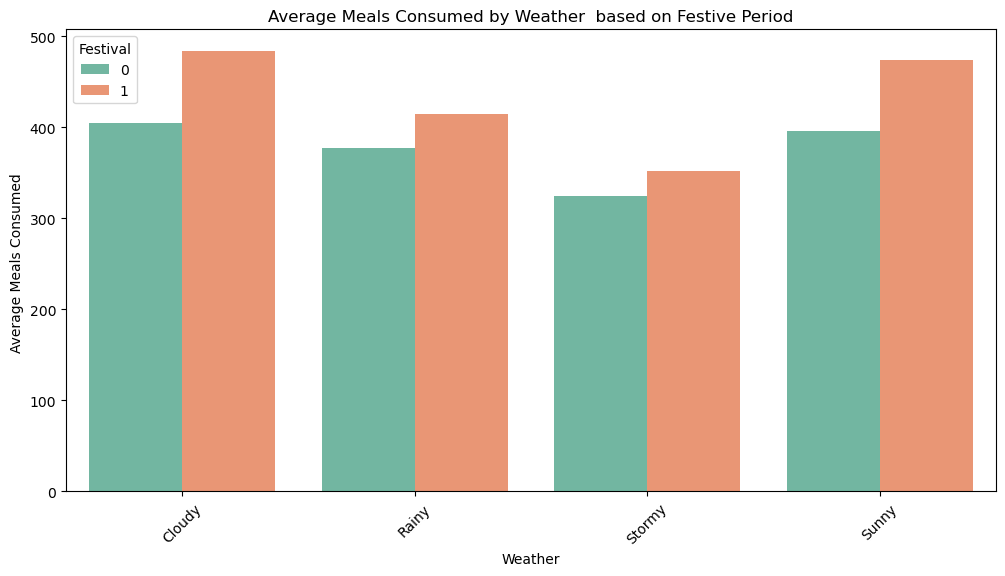

In [58]:


# Group by Day_of_Week and Festival, compute average meals consumed
day_festival_demand = df.groupby(['Festival','Weather'])['Meals_Consumed'].mean().reset_index()

# Grouped bar chart
plt.figure(figsize=(12,6))
sns.barplot(x='Weather', y='Meals_Consumed', hue='Festival', data=day_festival_demand, palette='Set2')
plt.title("Average Meals Consumed by Weather  based on Festive Period")
plt.xlabel("Weather")
plt.ylabel("Average Meals Consumed ")
plt.xticks(rotation=45)
plt.show()

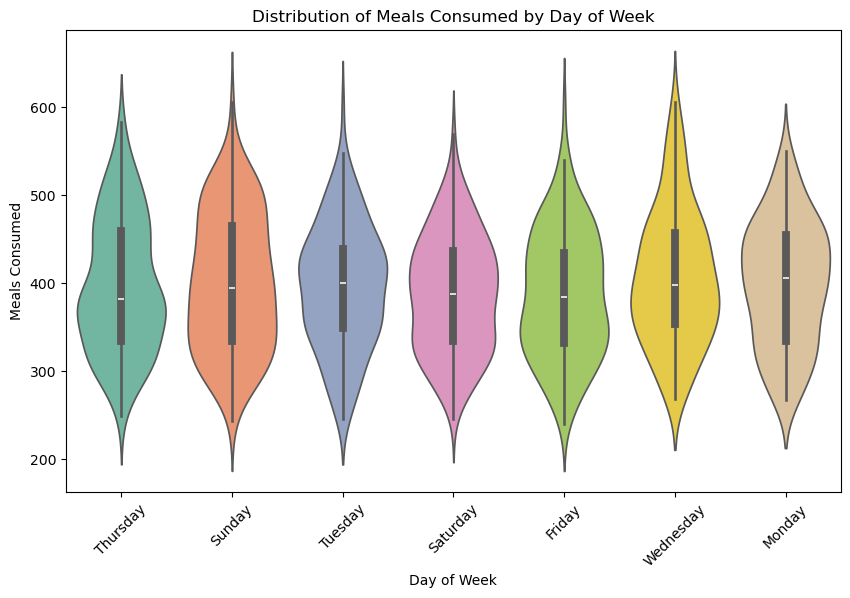

In [59]:
plt.figure(figsize=(10,6))
sns.violinplot(x="Day_of_Week", y="Meals_Consumed", order=df['Day_of_Week'].value_counts(ascending=False).index,data=df, palette="Set2")
plt.title("Distribution of Meals Consumed by Day of Week")
plt.ylabel("Meals Consumed")
plt.xlabel("Day of Week")
plt.xticks(rotation=45)
plt.show()


Day_of_Week
Wednesday    406.531250
Sunday       401.369128
Monday       399.850000
Thursday     397.725610
Tuesday      396.073826
Saturday     388.227586
Friday       387.075862
Name: Meals_Consumed, dtype: float64


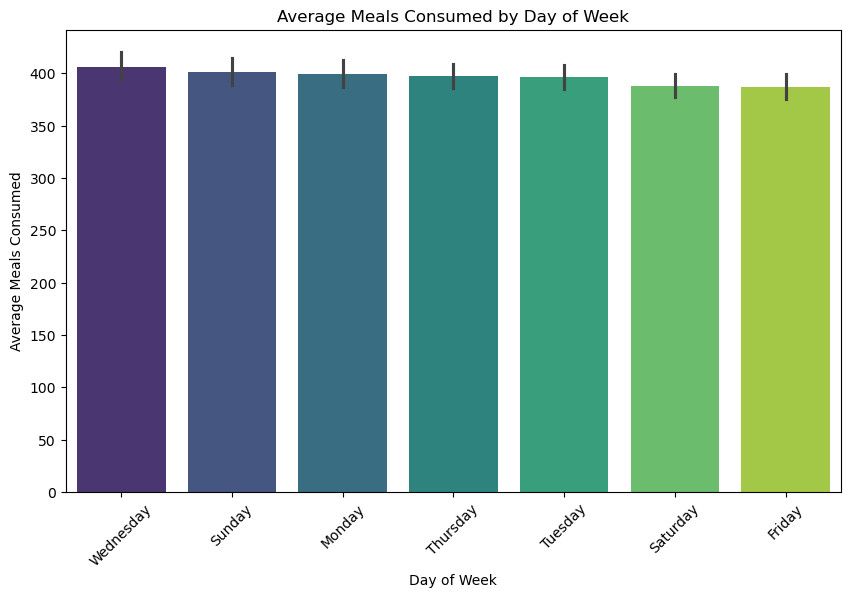

In [60]:
order = df.groupby('Day_of_Week')['Meals_Consumed'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
print(order)

sns.barplot(x='Day_of_Week', y='Meals_Consumed',
            order=order.index, data=df, palette='viridis')
plt.title("Average Meals Consumed by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Meals Consumed")
plt.xticks(rotation=45)
plt.show()

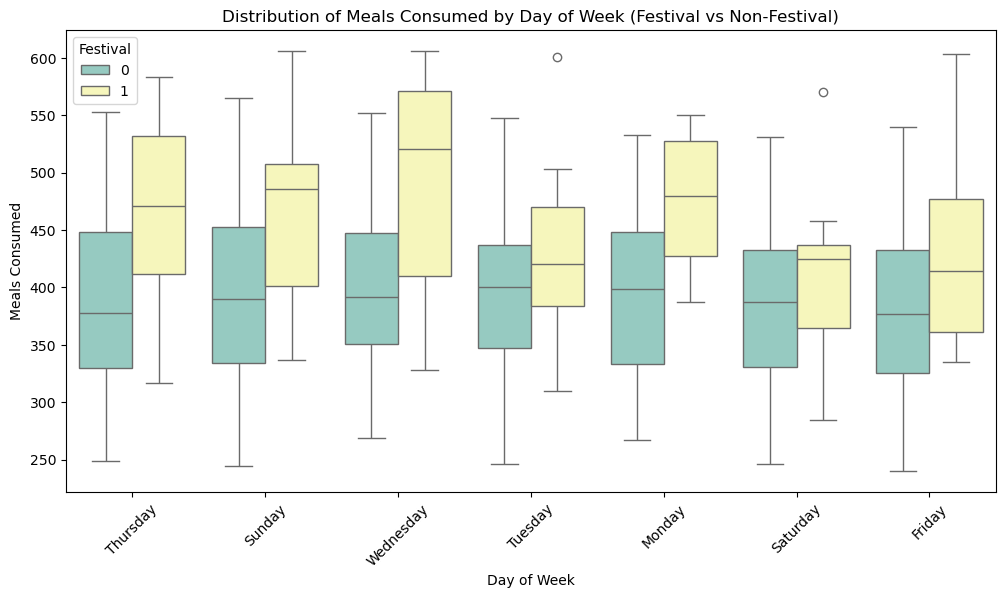

In [61]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Day_of_Week', y='Meals_Consumed', hue='Festival', data=df, palette='Set3')
plt.title("Distribution of Meals Consumed by Day of Week (Festival vs Non-Festival)")
plt.xlabel("Day of Week")
plt.ylabel("Meals Consumed")
plt.xticks(rotation=45)
plt.show()


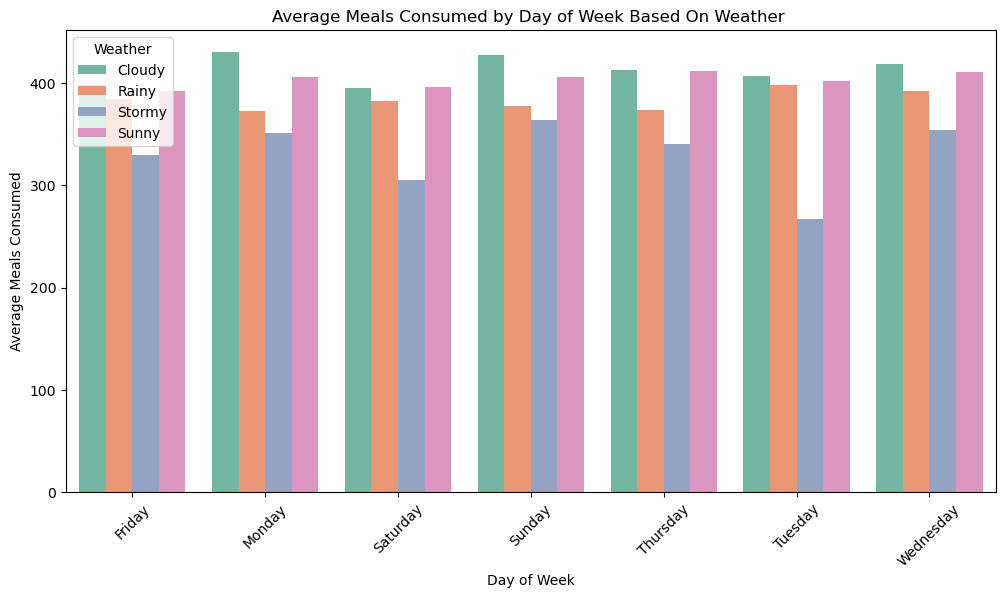

In [62]:

# Group by Day_of_Week and Festival, compute average meals consumed
day_Weather_demand = df.groupby(['Day_of_Week','Weather'])['Meals_Consumed'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='Day_of_Week', y='Meals_Consumed', hue='Weather', data=day_Weather_demand, palette='Set2')
plt.title("Average Meals Consumed by Day of Week Based On Weather ")
plt.xlabel("Day of Week")
plt.ylabel("Average Meals Consumed")
plt.xticks(rotation=45)
plt.show()

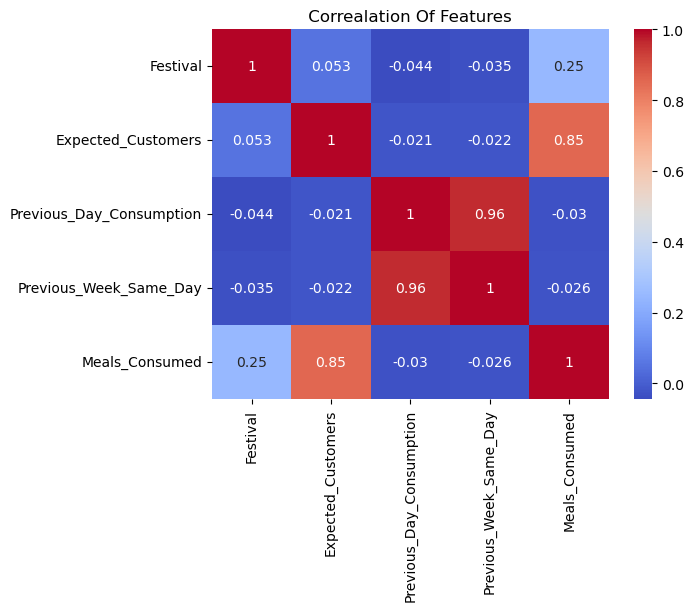

In [63]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title(" Correalation Of Features ")

plt.show()

### DATA PREPROCESSING

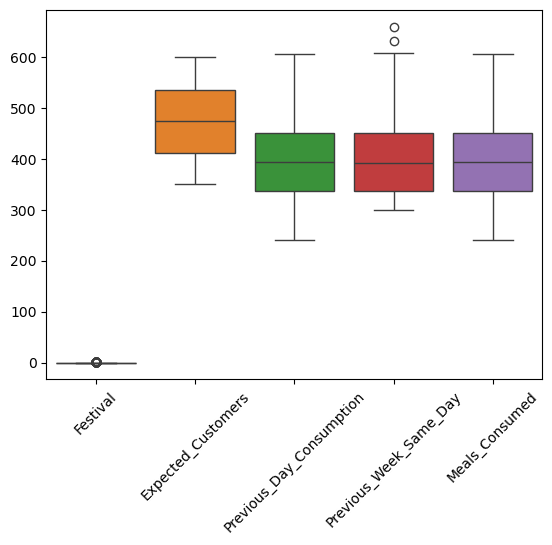

In [64]:
sns.boxplot(df)
plt.xticks(rotation=45)
plt.show()

In [65]:
## outliers Removale
def cap_outliers_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))
    return df
df=cap_outliers_IQR(df,"Previous_Week_Same_Day")

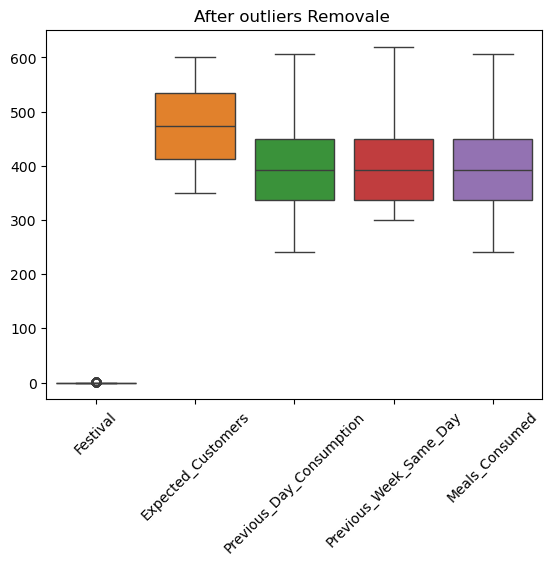

In [66]:
sns.boxplot(df)
plt.title("After outliers Removale ")
plt.xticks(rotation=45)
plt.show()


In [67]:
# Encode categorical features
le_day = OrdinalEncoder()
le_weather = LabelEncoder()
df1=df.copy()
df1['Day_of_Week'] = le_day.fit_transform(df1[['Day_of_Week']])
df1['Weather'] = le_weather.fit_transform(df1[['Weather']])
# Festival is already binary (0/1)
df1.head()



,Day_of_Week,Festival,Weather,Expected_Customers,Previous_Day_Consumption,Previous_Week_Same_Day,Meals_Consumed
0,4.0,0,0,572,352,361.0,512
1,3.0,0,1,486,512,509.0,385
2,6.0,0,3,516,385,390.0,460
3,3.0,0,1,462,460,480.0,337
4,4.0,0,0,402,337,327.0,316


In [68]:
df['Day_of_Week'].value_counts()

Day_of_Week
Thursday     164
Sunday       149
Tuesday      149
Saturday     145
Friday       145
Wednesday    128
Monday       120
Name: count, dtype: int64

## Feature Engineering

In [69]:
# Weekend indicator (when 2=Saturday, 3=Sunday after encoding)
df1['Weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x in ['Saturday','Sunday'] else 0)

# Demand lag feature
df1['Demand_Lag'] = df['Previous_Day_Consumption']

df1['Historical_Trend'] = (df1['Previous_Day_Consumption'] + df1['Previous_Week_Same_Day']) / 2
df.head()


,Day_of_Week,Festival,Weather,Expected_Customers,Previous_Day_Consumption,Previous_Week_Same_Day,Meals_Consumed
0,Thursday,0,Cloudy,572,352,361.0,512
1,Sunday,0,Rainy,486,512,509.0,385
2,Wednesday,0,Sunny,516,385,390.0,460
3,Sunday,0,Rainy,462,460,480.0,337
4,Thursday,0,Cloudy,402,337,327.0,316


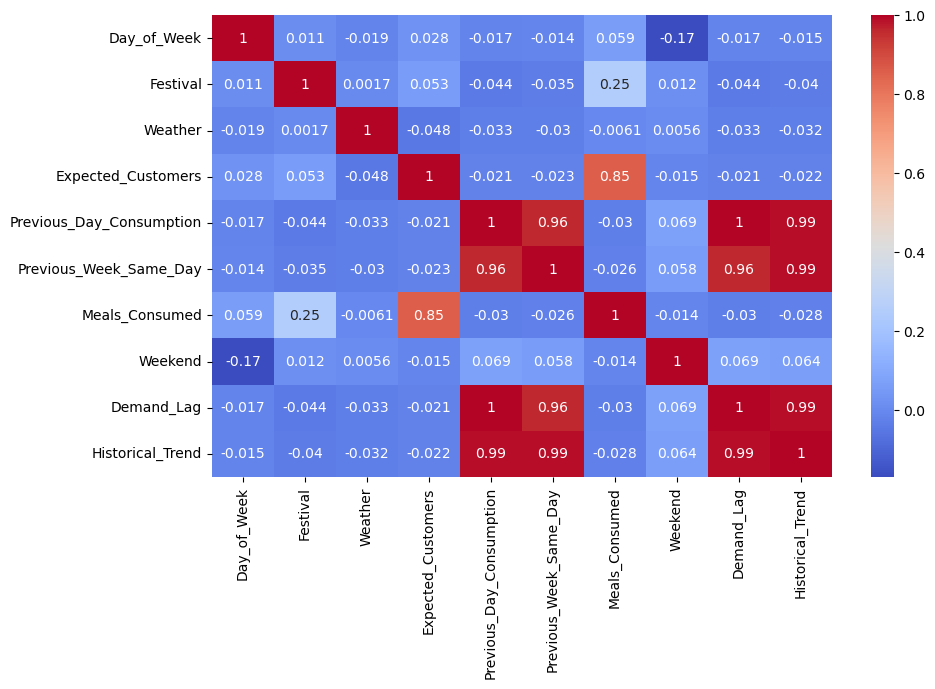

In [84]:
### Checking Multicolineality
plt.figure(figsize=(10,6))

sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## Feature Selection


In [71]:
df_select=df1.drop(["Previous_Week_Same_Day","Previous_Day_Consumption"],axis=1)
df_select.head()

,Day_of_Week,Festival,Weather,Expected_Customers,Meals_Consumed,Weekend,Demand_Lag,Historical_Trend
0,4.0,0,0,572,512,0,352,356.5
1,3.0,0,1,486,385,1,512,510.5
2,6.0,0,3,516,460,0,385,387.5
3,3.0,0,1,462,337,1,460,470.0
4,4.0,0,0,402,316,0,337,332.0


## Dataset Spliting Scalling

In [72]:

X = df_select.drop('Meals_Consumed', axis=1)
y = df_select['Meals_Consumed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scale=StandardScaler()
###  Scaling didn't add any importance in traing
#X_train_scaled=scale.fit_transform(X_train)
#X_test_scaled=scale.transform(X_test)


In [73]:
#! pip install  xgboost


## Model Training  And Evaluation

In [74]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
## Models Used
models = {
    "LogisticRegression":LogisticRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    #"XGBoost": XGBRegressor()
}
## Model Building And Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")


LogisticRegression -> MAE: 48.61, RMSE: 62.39
RandomForest -> MAE: 26.09, RMSE: 32.16
GradientBoosting -> MAE: 23.98, RMSE: 29.19


### Model Selection

In [75]:
model=GradientBoostingRegressor()
model.fit(X_train,y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f" MAE: {mae:.2f}, RMSE: {rmse:.2f}")

 MAE: 23.99, RMSE: 29.20


In [76]:
## Feature Importance
importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df=importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


              Feature  Importance
3  Expected_Customers    0.844886
2             Weather    0.077008
1            Festival    0.047483
5          Demand_Lag    0.012979
6    Historical_Trend    0.008370
0         Day_of_Week    0.008280
4             Weekend    0.000993


## Selecting Features Base on model.feature_importances_

In [77]:
importance_df.head(7)

,Feature,Importance
3,Expected_Customers,0.844886
2,Weather,0.077008
1,Festival,0.047483
5,Demand_Lag,0.012979
6,Historical_Trend,0.008370
0,Day_of_Week,0.008280
4,Weekend,0.000993


In [78]:
x=df1[['Expected_Customers','Weather','Festival','Day_of_Week','Historical_Trend','Demand_Lag']]
y=df1['Meals_Consumed']


X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



In [79]:
model=GradientBoostingRegressor()
model.fit(X_train,y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f" MAE: {mae:.2f}, RMSE: {rmse:.2f}")

 MAE: 23.59, RMSE: 28.96


## Model Pipeline  and Saving Of Pipelin

In [80]:

# 1. Custom function for feature engineering + outlier handling + selection
def preprocess_features(df):   # must accept y=None
    X = df.copy()

    # Outlier handling
    if 'Expected_Customers' in X.columns:
        Q1 = X["Expected_Customers"].quantile(0.25)
        Q3 = X["Expected_Customers"].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
    
        X["Expected_Customers"] = np.where(X["Expected_Customers"] < lower_bound, lower_bound,
                          np.where(X["Expected_Customers"] > upper_bound, upper_bound, X["Expected_Customers"]))
        

    # Feature engineering
    if {'Previous_Day_Consumption','Previous_Week_Same_Day'}.issubset(X.columns):
        X['Historical_Trend'] = (X['Previous_Day_Consumption'] + X['Previous_Week_Same_Day']) / 2

    if {'Expected_Customers','Previous_Day_Consumption'}.issubset(X.columns):
        X['Demand_Lag'] = X['Expected_Customers'] - X['Previous_Day_Consumption']

    # Feature selection
    selected_features = [
        'Expected_Customers',
        'Weather',
        'Festival',
        'Day_of_Week',
        'Historical_Trend',
        'Demand_Lag'
    ]
    return X[selected_features]

# Wrap in a transformer (validate=False avoids array shape issues with pandas)
feature_selector = FunctionTransformer(preprocess_features, validate=False)

# 2. Preprocessing for categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('weather', OneHotEncoder(handle_unknown='ignore'), ['Weather']),
        ('day', OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1), ['Day_of_Week'])
    ],
    remainder='passthrough'
)

# 3. Full pipeline (feature engineering + preprocessing + model)
pipeline = Pipeline(steps=[
    ('feature_selector', feature_selector),
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor())
])

# 4. Load dataset and split
df = pd.read_csv('food_waste_prediction_dataset_1000_rows.csv')

X = df[['Day_of_Week','Festival','Weather','Expected_Customers',
        'Previous_Day_Consumption','Previous_Week_Same_Day']]
y = df['Meals_Consumed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the pipeline
pipeline.fit(X_train, y_train)

# 6. Save the pipeline
joblib.dump(pipeline, "company_food_waste_pipeline.pkl")



['company_food_waste_pipeline.pkl']

In [81]:
print(pipeline)


Pipeline(steps=[('feature_selector',
                 FunctionTransformer(func=<function preprocess_features at 0x000001ED98A9F550>)),
                ('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('weather',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Weather']),
                                                 ('day',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Day_of_Week'])])),
                ('model', GradientBoostingRegressor())])


## Testing Pipeline

In [82]:
import pandas as pd
import joblib

# 1. Load your saved pipeline
pipeline = joblib.load("company_food_waste_pipeline.pkl")

# 2. Create a new raw input (same structure as company DB)
new_data = pd.DataFrame([{
    'Day_of_Week': 'Monday',
    'Festival': 0,
    'Weather': 'Sunny',
    'Expected_Customers': 120,
    'Previous_Day_Consumption': 100,
    'Previous_Week_Same_Day': 110,
}])

# 3. Run prediction
prediction = pipeline.predict(new_data)

print("Predicted Meals Consumed:", prediction[0])


Predicted Meals Consumed: 297.9785892033717


In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 23.59254061847698
RMSE: 28.961596952965042
R²: 0.8160600019780533
